NILAI MEDIAN DARI 5 SAMPEL PENGUJIAN
                          CLS    FCP   TBT     SI    LCP
Login                  0.0000   1.00   0.0   2.60   7.70
Dashboard Utama        0.0000   1.60  10.0   1.50   1.60
Notifikasi             0.0110   0.70   0.0   0.90   0.80
Greenhouse             0.0000   0.60   0.0   1.50   2.40
Detail Greenhouse      0.0000  19.10   0.0  19.40  20.10
Tandon                 0.0000   0.60   0.0   0.60   0.70
Detail Tandon          0.0000  15.00   0.0  13.60  15.50
Robot                  0.0000   0.60   0.0   0.60   0.70
Robot Detail           0.0000   2.80   0.0   2.00   2.80
Monitoring Sensor      0.0000  16.40   0.0  16.40  16.40
Lihat Detail Sensor    0.0000   3.25   0.0   2.85   3.25
Controlling            0.0000   9.10   0.0   8.80   9.10
Lihat Detail Aktuator  0.0000   1.90   0.0   1.40   1.90
Automasi Sensor        0.0000   1.50   0.0   1.20   1.70
Automasi Jadwal        0.0007   1.50   0.0   1.30   1.50
Kelola User            0.0030   0.70   0.0   0.70  

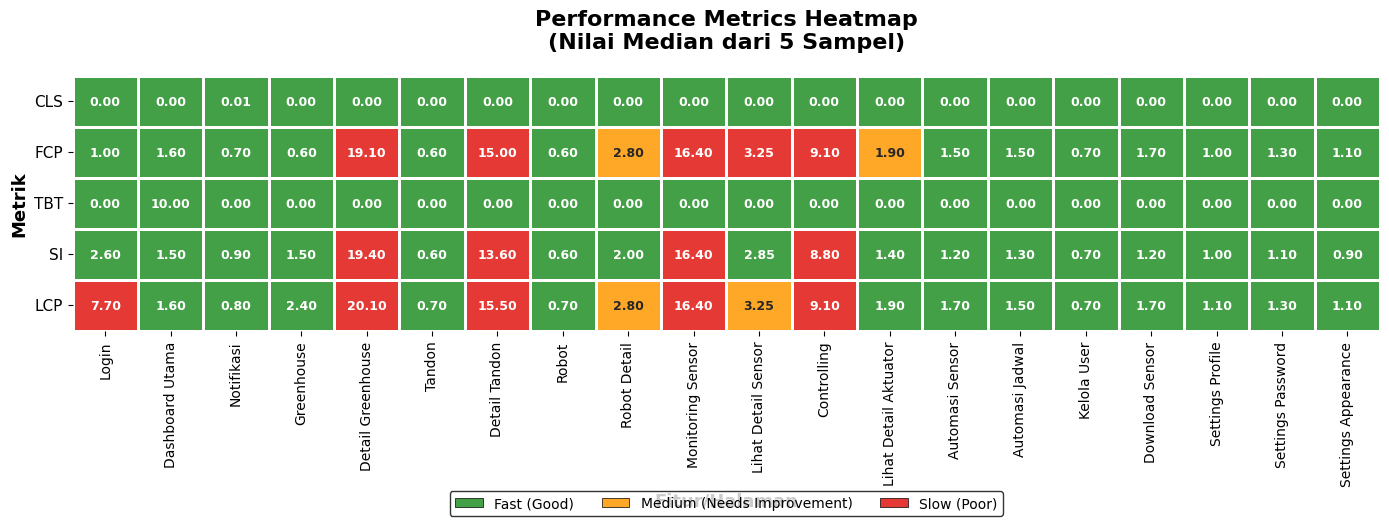

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Data raw dari pengujian (5 sampel untuk setiap fitur dan metrik)
raw_data = {
    'Login': {
        'CLS': [0, 0, 0, 0, 0],
        'FCP': [1, 4.5, 1.3, 1.0, 1.0],
        'TBT': [0, 0, 0, 0, 0],
        'SI': [2.6, 5.8, 2.7, 1.8, 2.3],
        'LCP': [7.7, 12.2, 7.3, 7.1, 12.4]
    },
    'Dashboard Utama': {
        'CLS': [0, 0, 0, 0, 0],
        'FCP': [2.3, 1.2, 1.6, 1.6, 1.9],
        'TBT': [10, 10, 10, 10, 10],
        'SI': [2.1, 1.4, 1.5, 1.5, 1.7],
        'LCP': [2.3, 1.2, 1.6, 1.6, 1.9]
    },
    'Notifikasi': {
        'CLS': [0, 0.017, 0.011, 0.018, 0],
        'FCP': [0.4, 0.7, 2.2, 0.4, 2.2],
        'TBT': [0, 0, 0, 0, 0],
        'SI': [0.7, 0.9, 2.2, 0.7, 2.4],
        'LCP': [0.5, 0.8, 2.2, 0.5, 2.3]
    },
    'Greenhouse': {
        'CLS': [0, 0, 0, 0, 0],
        'FCP': [1, 0.6, 0.8, 0.4, 0.4],
        'TBT': [0, 0, 0, 0, 0],
        'SI': [2.0, 1.5, 1.8, 0.5, 1.0],
        'LCP': [3.1, 2.4, 2.7, 0.6, 1.5]
    },
    'Detail Greenhouse': {
        'CLS': [np.nan, 0, np.nan, np.nan, np.nan],
        'FCP': [np.nan, 19.1, np.nan, np.nan, np.nan],
        'TBT': [np.nan, 0, np.nan, np.nan, np.nan],
        'SI': [np.nan, 19.4, np.nan, np.nan, np.nan],
        'LCP': [np.nan, 20.1, np.nan, np.nan, np.nan]
    },
    'Tandon': {
        'CLS': [0, 0, 0, 0, 0],
        'FCP': [0.5, 0.5, 1.5, 0.6, 2.3],
        'TBT': [0, 0, 0, 0, 0],
        'SI': [0.6, 0.5, 1.6, 0.6, 2.0],
        'LCP': [0.6, 0.5, 1.9, 0.7, 3.0]
    },
    'Detail Tandon': {
        'CLS': [0, 0, 0, 0, 0],
        'FCP': [19.0, 15.0, 10.9, 18.1, 11.4],
        'TBT': [0, 0, 0, 0, 0],
        'SI': [16.1, 13.6, 10.9, 15.4, 11.1],
        'LCP': [19.4, 15.5, 11, 18.6, 11.5]
    },
    'Robot': {
        'CLS': [0, 0, 0, 0, 0],
        'FCP': [0.6, 1.8, 0.5, 1.3, 0.5],
        'TBT': [0, 0, 0, 0, 0],
        'SI': [0.6, 1.4, 0.5, 1.1, 0.5],
        'LCP': [0.7, 1.8, 0.5, 1.3, 0.7]
    },
    'Robot Detail': {
        'CLS': [0, 0, 0, 0, 0],
        'FCP': [10, 2.8, 2.8, 7.7, 2.8],
        'TBT': [0, 0, 0, 0, 0],
        'SI': [6, 2, 1.9, 4.6, 1.9],
        'LCP': [10, 2.8, 2.8, 7.7, 2.8]
    },
    'Monitoring Sensor': {
        'CLS': [0, 0, 0, 0, 0],
        'FCP': [21.1, 16.2, 10.5, 16.4, 16.7],
        'TBT': [0, 0, 0, 0, 0],
        'SI': [21.2, 16.2, 10.5, 16.4, 16.7],
        'LCP': [21.1, 16.2, 10.5, 16.4, 16.8]
    },
    'Lihat Detail Sensor': {
        'CLS': [np.nan, 0, 0, 0, 0],
        'FCP': [np.nan, 4.0, 2.4, 2.5, 20.2],
        'TBT': [np.nan, 0, 0, 0, 0],
        'SI': [np.nan, 3.2, 2.5, 2.5, 20.2],
        'LCP': [np.nan, 4.0, 2.4, 2.5, 20.2]
    },
    'Controlling': {
        'CLS': [0, 0, 0, 0, 0],
        'FCP': [8.8, 9.3, 9.3, 2.8, 9.1],
        'TBT': [0, 0, 0, 0, 0],
        'SI': [8.8, 9.3, 9.4, 2.7, 8.3],
        'LCP': [8.8, 9.3, 9.3, 2.8, 9.1]
    },
    'Lihat Detail Aktuator': {
        'CLS': [0, 0, 0, 0, 0],
        'FCP': [1.8, 1.9, 2.0, 1.8, 2.1],
        'TBT': [0, 0, 0, 0, 0],
        'SI': [2.1, 1.4, 8.1, 1.4, 1.4],
        'LCP': [1.8, 1.9, 2.0, 1.8, 2.1]
    },
    'Automasi Sensor': {
        'CLS': [0, 0, 0, 0, 0],
        'FCP': [1.7, 1.5, 0.4, 0.4, 1.9],
        'TBT': [0, 0, 0, 0, 0],
        'SI': [1.2, 1.4, 0.5, 0.4, 1.2],
        'LCP': [1.7, 2.0, 0.4, 0.4, 1.9]
    },
    'Automasi Jadwal': {
        'CLS': [0.0007, 0.0007, 0, 0, 0.0007],
        'FCP': [0.7, 0.4, 1.5, 2, 2],
        'TBT': [0, 0, 0, 0, 0],
        'SI': [0.8, 0.5, 1.3, 1.8, 1.6],
        'LCP': [0.7, 0.5, 1.5, 2, 2.1]
    },
    'Kelola User': {
        'CLS': [0.003, 0.003, 0, 0.003, 0.003],
        'FCP': [0.7, 1.2, 0.7, 0.7, 2],
        'TBT': [0, 0, 0, 0, 0],
        'SI': [0.7, 0.9, 0.7, 0.7, 1.4],
        'LCP': [0.7, 1.3, 0.7, 0.7, 2.0]
    },
    'Download Sensor': {
        'CLS': [0, 0, 0, 0, 0],
        'FCP': [1.7, 2.2, 0.9, 1, 1.7],
        'TBT': [0, 0, 0, 0, 0],
        'SI': [1.2, 1.6, 0.9, 1, 1.3],
        'LCP': [1.7, 2.2, 0.9, 1, 1.7]
    },
    'Settings Profile': {
        'CLS': [0, 0, 0, 0, 0],
        'FCP': [1.7, 0.4, 2.3, 1, 0.5],
        'TBT': [0, 0, 0, 0, 0],
        'SI': [1.2, 0.4, 1.4, 1, 0.5],
        'LCP': [1.7, 0.4, 2.3, 1.1, 0.5]
    },
    'Settings Password': {
        'CLS': [0, 0, 0, 0, 0],
        'FCP': [0.8, 1.6, 2.1, 0.9, 1.3],
        'TBT': [0, 0, 0, 0, 0],
        'SI': [0.8, 1.1, 1.5, 0.9, 1.1],
        'LCP': [0.8, 1.7, 2.1, 0.9, 1.3]
    },
    'Settings Appearance': {
        'CLS': [0, 0, 0, 0, 0],
        'FCP': [0.8, 1.8, 2, 0.6, 1.1],
        'TBT': [0, 0, 0, 0, 0],
        'SI': [0.8, 1.3, 1.3, 0.6, 0.9],
        'LCP': [0.8, 1.8, 2.0, 0.6, 1.1]
    }
}

# Benchmark thresholds
benchmarks = {
    'FCP': {'fast': 1.8, 'medium': 3},
    'LCP': {'fast': 2.5, 'medium': 4},
    'TBT': {'fast': 200, 'medium': 600},
    'CLS': {'fast': 0.1, 'medium': 0.25},
    'SI': {'fast': 3.4, 'medium': 5.8}
}

# Fungsi untuk menghitung median
def calculate_median(values):
    filtered = [v for v in values if not np.isnan(v)]
    if len(filtered) == 0:
        return np.nan
    return np.median(filtered)

# Fungsi untuk menentukan kategori performa
def categorize_performance(value, metric):
    if np.isnan(value):
        return -1  # No data
    
    benchmark = benchmarks[metric]
    if value <= benchmark['fast']:
        return 2  # Fast (Green)
    elif value <= benchmark['medium']:
        return 1  # Medium (Yellow)
    else:
        return 0  # Slow (Red)

# Hitung median untuk setiap fitur dan metrik
metrics = ['CLS', 'FCP', 'TBT', 'SI', 'LCP']
features = list(raw_data.keys())

median_data = {}
category_data = {}

for feature in features:
    median_data[feature] = {}
    category_data[feature] = {}
    for metric in metrics:
        median_value = calculate_median(raw_data[feature][metric])
        median_data[feature][metric] = median_value
        category_data[feature][metric] = categorize_performance(median_value, metric)

# Buat DataFrame untuk visualisasi
df_median = pd.DataFrame(median_data).T
df_category = pd.DataFrame(category_data).T

# Cetak hasil median
print("=" * 80)
print("NILAI MEDIAN DARI 5 SAMPEL PENGUJIAN")
print("=" * 80)
print(df_median.round(4))
print("\n")

# Cetak statistik summary
print("=" * 80)
print("STATISTIK SUMMARY")
print("=" * 80)
for metric in metrics:
    values = df_median[metric].dropna()
    print(f"\n{metric}:")
    print(f"  Average: {values.mean():.4f}")
    print(f"  Min: {values.min():.4f}")
    print(f"  Max: {values.max():.4f}")
    print(f"  Std Dev: {values.std():.4f}")

# Warna solid: Hijau, Kuning, Merah (tanpa gradasi)
colors = ['#e53935', '#ffa726', '#43a047']  # Red, Yellow, Green (solid)
cmap = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5]
norm = BoundaryNorm(bounds, cmap.N)

# Export ke CSV
df_median.to_csv('performance_median_data.csv')
print("\nData median berhasil diekspor ke 'performance_median_data.csv'")

# Analisis halaman dengan performa terburuk
print("\n" + "=" * 80)
print("ANALISIS PERFORMA")
print("=" * 80)

# Hitung score total (semakin tinggi semakin baik, -1 untuk no data diabaikan)
total_scores = df_category.replace(-1, np.nan).sum(axis=1)
sorted_features = total_scores.sort_values()

print("\n5 Halaman dengan Performa TERBAIK:")
for i, (feature, score) in enumerate(sorted_features.tail(5).items(), 1):
    print(f"{i}. {feature} (Score: {score:.0f})")

print("\n5 Halaman dengan Performa TERBURUK:")
for i, (feature, score) in enumerate(sorted_features.head(5).items(), 1):
    print(f"{i}. {feature} (Score: {score:.0f})")

# Identifikasi metrik yang paling bermasalah
print("\n" + "=" * 80)
print("METRIK YANG PERLU DIPERBAIKI")
print("=" * 80)
for metric in metrics:
    slow_count = (df_category[metric] == 0).sum()
    medium_count = (df_category[metric] == 1).sum()
    fast_count = (df_category[metric] == 2).sum()
    total = len(df_category) - (df_category[metric] == -1).sum()
    
    if total > 0:
        slow_pct = (slow_count / total) * 100
        medium_pct = (medium_count / total) * 100
        fast_pct = (fast_count / total) * 100
        
        print(f"\n{metric}:")
        print(f"  Fast: {fast_count}/{total} ({fast_pct:.1f}%)")
        print(f"  Medium: {medium_count}/{total} ({medium_pct:.1f}%)")
        print(f"  Slow: {slow_count}/{total} ({slow_pct:.1f}%)")
        
        if slow_pct > 30:
            print(f"  >>> PRIORITAS TINGGI - Lebih dari 30% halaman memiliki performa buruk!")
        elif slow_pct > 10:
            print(f"  >>> PERLU PERHATIAN - Beberapa halaman memiliki performa buruk")
            
# Visualisasi Heatmap - Hanya 1 gambar dengan 3 warna solid
fig, ax = plt.subplots(figsize=(14, 6))
fig.subplots_adjust(bottom=0.28)

# Warna solid: Hijau, Kuning, Merah (tanpa gradasi)
colors = ['#e53935', '#ffa726', '#43a047']  # Red, Yellow, Green (solid)
cmap = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5]
norm = BoundaryNorm(bounds, cmap.N)

# Data ditranspos supaya fitur berada pada sumbu X
heatmap_data = df_category.T
annot_data = df_median.T.round(2)

sns.heatmap(
    heatmap_data,
    annot=annot_data,
    fmt='.2f',
    cmap=cmap,
    norm=norm,
    cbar=False,
    ax=ax,
    linewidths=1,
    linecolor='white',
    annot_kws={'fontsize': 9, 'weight': 'bold'}
)

ax.set_title(
    'Performance Metrics Heatmap\n(Nilai Median dari 5 Sampel)',
    fontsize=16,
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Fitur/Halaman', fontsize=13, fontweight='bold')
ax.set_ylabel('Metrik', fontsize=13, fontweight='bold')

plt.xticks(rotation=90, ha='center', fontsize=10)
plt.yticks(rotation=0, fontsize=11)

legend_elements = [
    Patch(facecolor='#43a047', label='Fast (Good)', edgecolor='black', linewidth=0.5),
    Patch(facecolor='#ffa726', label='Medium (Needs Improvement)', edgecolor='black', linewidth=0.5),
    Patch(facecolor='#e53935', label='Slow (Poor)', edgecolor='black', linewidth=0.5)
]
ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.6),
    ncol=3,
    frameon=True,
    fontsize=10,
    edgecolor='black'
)

plt.tight_layout()
plt.savefig('performance_heatmap2.png', dpi=300, bbox_inches='tight')

NILAI MEDIAN LIGHTHOUSE SCORE DARI 5 SAMPEL PENGUJIAN
                         Performance  Accessibility  Best Practice   SEO
Login                           68.0           82.0          100.0  92.0
Dashboard Utama                 87.0           94.0          100.0  91.0
Greenhouse                      86.0          100.0          100.0  92.0
Greenhouse Detail               55.0           91.0          100.0  92.0
Tandon/Reservoir               100.0           96.0          100.0  92.0
Tandon/Reservoir Detail         55.0           91.0          100.0  92.0
Robot                          100.0           96.0           96.0  91.0
Robot Detail                    71.0           90.0           96.0  91.0
Monitoring                      55.0           92.0           96.0  91.0
Monitoring Detail               67.0           96.0          100.0  91.0
Controlling                     55.0           81.0           96.0  82.0
Controlling Detail              55.0           96.0          100.0  91

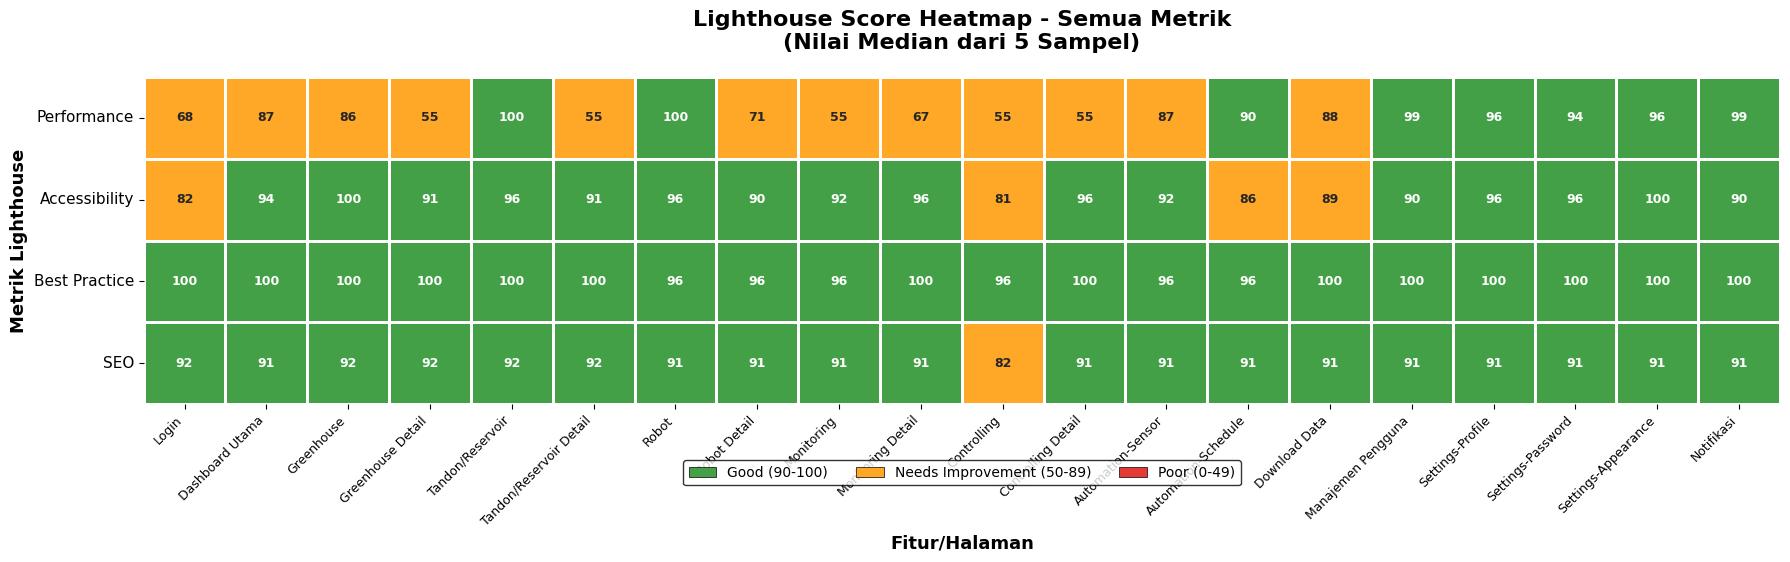


REKOMENDASI PRIORITAS PERBAIKAN

🟡 PRIORITAS SEDANG - Performance (Needs Improvement):
   Greenhouse Detail: 55.0
   Tandon/Reservoir Detail: 55.0
   Monitoring: 55.0

🟡 PRIORITAS SEDANG - Accessibility (Needs Improvement):
   Controlling: 81.0
   Login: 82.0
   Automation-Schedule: 86.0

🟡 PRIORITAS SEDANG - SEO (Needs Improvement):
   Controlling: 82.0


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Data raw dari pengujian Lighthouse (5 sampel untuk setiap fitur dan metrik)
raw_data = {
    'Login': {
        'Performance': [68, 55, 66, 71, 69],
        'Accessibility': [82, 82, 82, 82, 82],
        'Best Practice': [100, 100, 100, 100, 100],
        'SEO': [92, 92, 92, 92, 92]
    },
    'Dashboard Utama': {
        'Performance': [76, 94, 87, 88, 82],
        'Accessibility': [94, 94, 94, 94, 94],
        'Best Practice': [100, 100, 100, 100, 100],
        'SEO': [91, 91, 91, 91, 91]
    },
    'Greenhouse': {
        'Performance': [77, 86, 82, 100, 95],
        'Accessibility': [100, 100, 100, 100, 100],
        'Best Practice': [100, 100, 100, 100, 100],
        'SEO': [92, 92, 92, 92, 92]
    },
    'Greenhouse Detail': {
        'Performance': [55, np.nan, np.nan, np.nan, np.nan],
        'Accessibility': [91, np.nan, np.nan, np.nan, np.nan],
        'Best Practice': [100, np.nan, np.nan, np.nan, np.nan],
        'SEO': [92, np.nan, np.nan, np.nan, np.nan]
    },
    'Tandon/Reservoir': {
        'Performance': [100, 100, 85, 100, 72],
        'Accessibility': [96, 96, 96, 96, 96],
        'Best Practice': [100, 100, 100, 100, 100],
        'SEO': [92, 92, 92, 92, 92]
    },
    'Tandon/Reservoir Detail': {
        'Performance': [55, 55, 55, 55, 55],
        'Accessibility': [91, 91, 91, 91, 91],
        'Best Practice': [100, 100, 100, 100, 100],
        'SEO': [92, 92, 92, 92, 92]
    },
    'Robot': {
        'Performance': [100, 85, 100, 93, 100],
        'Accessibility': [96, 96, 96, 96, 96],
        'Best Practice': [96, 96, 96, 96, 96],
        'SEO': [91, 91, 91, 91, 91]
    },
    'Robot Detail': {
        'Performance': [55, 71, 72, 56, 72],
        'Accessibility': [90, 90, 90, 90, 90],
        'Best Practice': [96, 96, 96, 96, 96],
        'SEO': [91, 91, 91, 91, 91]
    },
    'Monitoring': {
        'Performance': [55, 55, 55, 55, 55],
        'Accessibility': [92, 92, 92, 92, 88],
        'Best Practice': [96, 96, 96, 96, 96],
        'SEO': [91, 91, 91, 91, 91]
    },
    'Monitoring Detail': {
        'Performance': [62, 73, 72, 55, np.nan],
        'Accessibility': [96, 96, 96, 96, np.nan],
        'Best Practice': [100, 100, 100, 100, np.nan],
        'SEO': [91, 91, 91, 91, np.nan]
    },
    'Controlling': {
        'Performance': [55, 55, 55, 69, 55],
        'Accessibility': [81, 81, 81, 81, 81],
        'Best Practice': [96, 96, 96, 96, 96],
        'SEO': [82, 82, 82, 82, 82]
    },
    'Controlling Detail': {
        'Performance': [55, 55, 55, 55, 55],
        'Accessibility': [96, 96, 96, 96, 96],
        'Best Practice': [100, 100, 100, 100, 100],
        'SEO': [91, 91, 91, 91, 91]
    },
    'Automation-Sensor': {
        'Performance': [87, 85, 100, 100, 84],
        'Accessibility': [92, 92, 92, 92, 92],
        'Best Practice': [96, 96, 96, 96, 96],
        'SEO': [91, 91, 91, 91, 91]
    },
    'Automation-Schedule': {
        'Performance': [99, 100, 90, 80, 81],
        'Accessibility': [86, 86, 86, 86, 86],
        'Best Practice': [96, 96, 96, 96, 96],
        'SEO': [91, 91, 91, 91, 91]
    },
    'Download Data': {
        'Performance': [88, 79, 98, 97, 87],
        'Accessibility': [89, 89, 89, 89, 89],
        'Best Practice': [100, 100, 100, 100, 100],
        'SEO': [91, 91, 91, 91, 91]
    },
    'Manajemen Pengguna': {
        'Performance': [100, 94, 99, 100, 82],
        'Accessibility': [90, 90, 90, 90, 90],
        'Best Practice': [100, 100, 100, 100, 100],
        'SEO': [91, 91, 91, 91, 91]
    },
    'Settings-Profile': {
        'Performance': [87, 100, 79, 96, 100],
        'Accessibility': [96, 96, 96, 96, 96],
        'Best Practice': [100, 100, 100, 100, 100],
        'SEO': [91, 91, 91, 91, 91]
    },
    'Settings-Password': {
        'Performance': [99, 88, 81, 98, 94],
        'Accessibility': [96, 96, 96, 96, 96],
        'Best Practice': [100, 100, 100, 100, 100],
        'SEO': [91, 91, 91, 91, 91]
    },
    'Settings-Appearance': {
        'Performance': [99, 85, 83, 100, 96],
        'Accessibility': [100, 100, 100, 100, 100],
        'Best Practice': [100, 100, 100, 100, 100],
        'SEO': [91, 91, 91, 91, 91]
    },
    'Notifikasi': {
        'Performance': [100, 99, 76, 100, 75],
        'Accessibility': [90, 90, 90, 90, 90],
        'Best Practice': [100, 100, 100, 100, 100],
        'SEO': [91, 91, 91, 91, 91]
    }
}

# Benchmark thresholds untuk Lighthouse Score (0-100)
# Sesuai Tabel 3.16: Poor (0-49), Needs Improvement (50-89), Good (90-100)
benchmarks = {
    'Performance': {'good': 90, 'needs_improvement': 50},
    'Accessibility': {'good': 90, 'needs_improvement': 50},
    'Best Practice': {'good': 90, 'needs_improvement': 50},
    'SEO': {'good': 90, 'needs_improvement': 50}
}

# Fungsi untuk menghitung median
def calculate_median(values):
    filtered = [v for v in values if not np.isnan(v)]
    if len(filtered) == 0:
        return np.nan
    return np.median(filtered)

# Fungsi untuk menentukan kategori performa
def categorize_performance(value):
    if np.isnan(value):
        return -1  # No data
    
    if value >= 90:
        return 2  # Good (Green)
    elif value >= 50:
        return 1  # Needs Improvement (Yellow)
    else:
        return 0  # Poor (Red)

# Hitung median untuk setiap fitur dan metrik
metrics = ['Performance', 'Accessibility', 'Best Practice', 'SEO']
features = list(raw_data.keys())

median_data = {}
category_data = {}

for feature in features:
    median_data[feature] = {}
    category_data[feature] = {}
    for metric in metrics:
        median_value = calculate_median(raw_data[feature][metric])
        median_data[feature][metric] = median_value
        category_data[feature][metric] = categorize_performance(median_value)

# Buat DataFrame untuk visualisasi
df_median = pd.DataFrame(median_data).T
df_category = pd.DataFrame(category_data).T

# Cetak hasil median
print("=" * 90)
print("NILAI MEDIAN LIGHTHOUSE SCORE DARI 5 SAMPEL PENGUJIAN")
print("=" * 90)
print(df_median.round(1))
print("\n")

# Cetak statistik summary untuk semua metrik
print("=" * 90)
print("STATISTIK SUMMARY - SEMUA METRIK")
print("=" * 90)
for metric in metrics:
    values = df_median[metric].dropna()
    print(f"\n{metric}:")
    print(f"  Average: {values.mean():.2f}")
    print(f"  Min: {values.min():.2f}")
    print(f"  Max: {values.max():.2f}")
    print(f"  Std Dev: {values.std():.2f}")

# Export ke CSV
df_median.to_csv('lighthouse_median_data.csv')
print("\n" + "=" * 90)
print("Data median berhasil diekspor ke 'lighthouse_median_data.csv'")
print("=" * 90)

# Analisis untuk SEMUA metrik
print("\n" + "=" * 90)
print("ANALISIS DISTRIBUSI STATUS - SEMUA METRIK")
print("=" * 90)
for metric in metrics:
    poor_count = (df_category[metric] == 0).sum()
    needs_count = (df_category[metric] == 1).sum()
    good_count = (df_category[metric] == 2).sum()
    total = len(df_category) - (df_category[metric] == -1).sum()
    
    if total > 0:
        poor_pct = (poor_count / total) * 100
        needs_pct = (needs_count / total) * 100
        good_pct = (good_count / total) * 100
        
        print(f"\n{metric}:")
        print(f"  Good (90-100): {good_count}/{total} ({good_pct:.1f}%)")
        print(f"  Needs Improvement (50-89): {needs_count}/{total} ({needs_pct:.1f}%)")
        print(f"  Poor (0-49): {poor_count}/{total} ({poor_pct:.1f}%)")
        
        if poor_count > 0:
            print(f"  >>> ⚠️ ADA {poor_count} HALAMAN DENGAN STATUS POOR!")
        if needs_pct > 50:
            print(f"  >>> ⚠️ LEBIH DARI 50% HALAMAN PERLU IMPROVEMENT!")
        if good_pct == 100:
            print(f"  >>> ✓ SEMUA HALAMAN DALAM KONDISI GOOD!")

# Detail halaman dengan status Poor untuk setiap metrik
print("\n" + "=" * 90)
print("HALAMAN DENGAN STATUS POOR (0-49) PER METRIK")
print("=" * 90)
for metric in metrics:
    poor_pages = df_median[df_median[metric] < 50][metric].sort_values()
    if len(poor_pages) > 0:
        print(f"\n{metric}:")
        for page, score in poor_pages.items():
            print(f"  - {page}: {score:.1f}")
    else:
        print(f"\n{metric}: ✓ Tidak ada halaman dengan status Poor")

# Detail halaman dengan status Needs Improvement untuk setiap metrik
print("\n" + "=" * 90)
print("HALAMAN DENGAN STATUS NEEDS IMPROVEMENT (50-89) PER METRIK")
print("=" * 90)
for metric in metrics:
    needs_pages = df_median[(df_median[metric] >= 50) & (df_median[metric] < 90)][metric].sort_values()
    if len(needs_pages) > 0:
        print(f"\n{metric}:")
        for page, score in needs_pages.items():
            print(f"  - {page}: {score:.1f}")
    else:
        print(f"\n{metric}: ✓ Semua halaman sudah Good (≥90) atau tidak ada data")

# Hitung total score untuk ranking
print("\n" + "=" * 90)
print("RANKING HALAMAN BERDASARKAN TOTAL SCORE")
print("=" * 90)
df_median['Total Score'] = df_median.sum(axis=1)
sorted_total = df_median.sort_values('Total Score', ascending=False)

print("\n5 Halaman dengan Total Score TERTINGGI:")
for i, (feature, row) in enumerate(sorted_total.head(5).iterrows(), 1):
    print(f"{i}. {feature}: {row['Total Score']:.1f} (P:{row['Performance']:.0f}, A:{row['Accessibility']:.0f}, BP:{row['Best Practice']:.0f}, SEO:{row['SEO']:.0f})")

print("\n5 Halaman dengan Total Score TERENDAH:")
for i, (feature, row) in enumerate(sorted_total.tail(5).iterrows(), 1):
    print(f"{i}. {feature}: {row['Total Score']:.1f} (P:{row['Performance']:.0f}, A:{row['Accessibility']:.0f}, BP:{row['Best Practice']:.0f}, SEO:{row['SEO']:.0f})")

# Visualisasi Heatmap
# Hitung ukuran figure berdasarkan jumlah kolom dan baris untuk membuat square cells
n_rows = len(metrics)
n_cols = len(features)
cell_size = 0.8  # Ukuran setiap sel dalam inch
fig_width = n_cols * cell_size + 2  # Tambah margin
fig_height = n_rows * cell_size + 3  # Tambah margin untuk legend

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Warna solid: Merah (Poor), Kuning (Needs Improvement), Hijau (Good)
colors = ['#e53935', '#ffa726', '#43a047']  # Red, Yellow, Green
cmap = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5]
norm = BoundaryNorm(bounds, cmap.N)

# Data ditranspos supaya fitur berada pada sumbu X
heatmap_data = df_category.T
annot_data = df_median[metrics].T.round(0)

sns.heatmap(
    heatmap_data,
    annot=annot_data,
    fmt='.0f',
    cmap=cmap,
    norm=norm,
    cbar=False,
    ax=ax,
    linewidths=1,
    linecolor='white',
    annot_kws={'fontsize': 9, 'weight': 'bold'},
    square=True  # Membuat setiap cell menjadi square
)

ax.set_title(
    'Lighthouse Score Heatmap - Semua Metrik\n(Nilai Median dari 5 Sampel)',
    fontsize=16,
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Fitur/Halaman', fontsize=13, fontweight='bold')
ax.set_ylabel('Metrik Lighthouse', fontsize=13, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=11)

# Legend sesuai Tabel 3.16
legend_elements = [
    Patch(facecolor='#43a047', label='Good (90-100)', edgecolor='black', linewidth=0.5),
    Patch(facecolor='#ffa726', label='Needs Improvement (50-89)', edgecolor='black', linewidth=0.5),
    Patch(facecolor='#e53935', label='Poor (0-49)', edgecolor='black', linewidth=0.5)
]
ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=True,
    fontsize=10,
    edgecolor='black'
)

plt.tight_layout()
plt.savefig('lighthouse_heatmap_all_metrics.png', dpi=300, bbox_inches='tight')
print("\n" + "=" * 90)
print("Heatmap berhasil disimpan sebagai 'lighthouse_heatmap_all_metrics.png'")
print("=" * 90)
plt.show()

# Rekomendasi berdasarkan semua metrik
print("\n" + "=" * 90)
print("REKOMENDASI PRIORITAS PERBAIKAN")
print("=" * 90)

for metric in metrics:
    poor_pages = df_median[df_median[metric] < 50][metric].sort_values()
    needs_pages = df_median[(df_median[metric] >= 50) & (df_median[metric] < 90)][metric].sort_values()
    
    if len(poor_pages) > 0:
        print(f"\n🔴 PRIORITAS TINGGI - {metric} (Poor):")
        for page, score in poor_pages.items():
            print(f"   {page}: {score:.1f}")
    
    if len(needs_pages) > 0 and len(poor_pages) == 0:
        print(f"\n🟡 PRIORITAS SEDANG - {metric} (Needs Improvement):")
        for page, score in needs_pages.head(3).items():
            print(f"   {page}: {score:.1f}")

if df_median[df_median < 50].any().any() == False and df_median[df_median < 90].any().any() == False:
    print("\n✓ SEMUA METRIK DALAM KONDISI BAIK!")
    print("  Tidak ada halaman yang memerlukan perbaikan prioritas tinggi.")